In [12]:
import matplotlib.pyplot as plt
import numpy as np
from mossbauer_analysis import utils as u
from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer

In [156]:
def lorentzian(p,x):
    x0, Gamma, A, eta_nr = p
    return eta_nr-A*(Gamma/2)**2 / ((x-x0)**2 + (Gamma/2)**2)

In [175]:

v = np.linspace(-10,10,1000)    


#SOURCES
sourceFe = CobaltFe ()
sourceFe.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
sourceFe.update_params()

sourceRh = CobaltRhodium()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 500e-9
absorber.abundance = 0.95
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()

#CALCULATIONS
moss_Fe_Fe = Mossbauer(sourceFe, absorber)
moss_Rh_Fe = Mossbauer(sourceRh, absorber)

t_Fe_Fe = moss_Fe_Fe.total_transmission_rate_attenuated(v)
t_Rh_Fe = moss_Rh_Fe.total_transmission_rate_attenuated(v)

In [176]:
sourceFe.Gamma
absorber.Gamma

(1-sourceFe.fs)
1-moss_Fe_Fe.non_resonant_attenuation()

0.02480811414581441



Mean squared residual: 2.070e-07

Covariance Matrix:

       p[0]  p[1]  p[2]  p[3]
 p[0]  1.00
 p[1] -0.00  1.00
 p[2] -0.00 -0.53  1.00
 p[3] -0.00  0.57  0.09  1.00

Final Parameters:

 p[0] = -1.81723e-07 +/- 6.6e-05 (36441.02%)
 p[1] = 2.32084e-01 +/- 2.3e-04 (0.10%)
 p[2] = 3.75186e-01 +/- 2.1e-04 (0.06%)
 p[3] = 9.73084e-01 +/- 6.7e-05 (0.01%)

0.23208382549191806 0.18958333333333333


Text(0, 0.5, 'Normalized transmission')

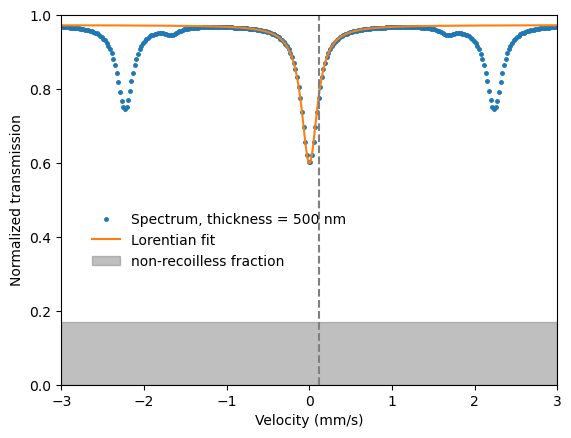

In [182]:
v = np.linspace(-10,10,1000)    

plt.plot(v, t_Fe_Fe ,'.',markersize = 5, label = 'Spectrum, thickness = 500 nm')
#plt.plot(v, t_Rh_Fe,'.',markersize = 1, label = 'Rh source')


p0 = [0, 0.2, 0.3, 0.1]
idx1 = np.argmin(np.abs(v+1))
idx2 = np.argmin(np.abs(v-1))
p,dp = u.fit(lorentzian, v[idx1:idx2], t_Fe_Fe[idx1:idx2],p0, fullout=True)
plt.plot(v, lorentzian(p,v), label = 'Lorentian fit')

plt.axhspan(0,(1-sourceFe.fs)*moss_Fe_Fe.non_resonant_attenuation(), color = 'gray', alpha = 0.5, label = 'non-recoilless fraction')

plt.axvline(Gamma_tot/2, color='gray', linestyle='--')

Gamma_tot = p[1]
Contrast = p[2]
print(p[1], sourceFe.Gamma+absorber.Gamma)

plt.legend(frameon=False, loc = (0.05,0.3))
#plt.axhline(0.6)
plt.ylim(0,1)
plt.xlim(-3,3)

plt.xlabel('Velocity (mm/s)')
plt.ylabel('Normalized transmission')

(-1.0, 1.0)

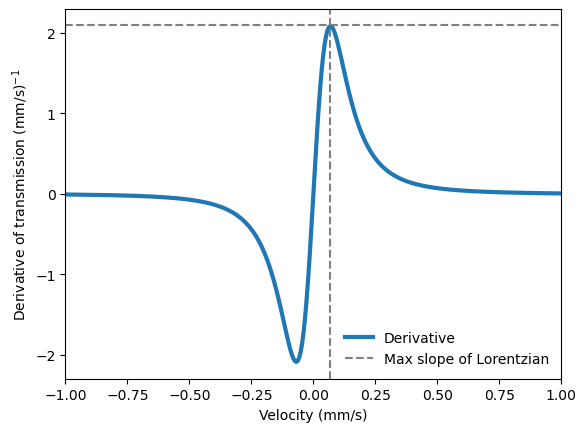

In [183]:
v = np.linspace(-10,10,1000)    
v = np.linspace(-3,3,1000)    
transmission = moss_Fe_Fe.total_transmission_rate_attenuated(v)
derivative = np.gradient(transmission, v[1]-v[0])
plt.plot(v, derivative, linewidth = 3,label='Derivative')

plt.axvline(Gamma_tot/2/np.sqrt(3), color='gray', linestyle='--')
#plt.plot(v, derivative*np.sqrt(transmission), label='Derivative*root(n)')

#v = np.linspace(0.035,0.1,20)
#transmission = moss_Fe_Fe.total_transmission_rate_attenuated(v)
#derivative = np.gradient(transmission, v[1]-v[0])

plt.axhline(3*np.sqrt(3)*Contrast/(4*Gamma_tot), color='gray', linestyle='--', label='Max slope of Lorentzian')
#plt.plot(v, derivative, label='Derivative')
plt.legend(frameon=False)
plt.xlabel('Velocity (mm/s)')
plt.ylabel('Derivative of transmission (mm/s)$^{-1}$')

plt.xlim(-1,1)

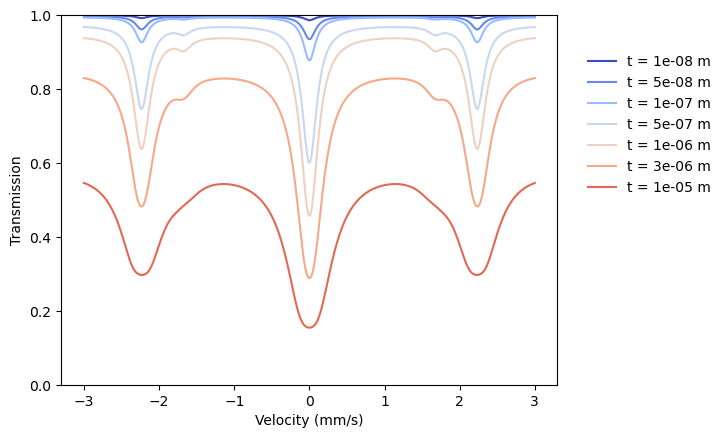

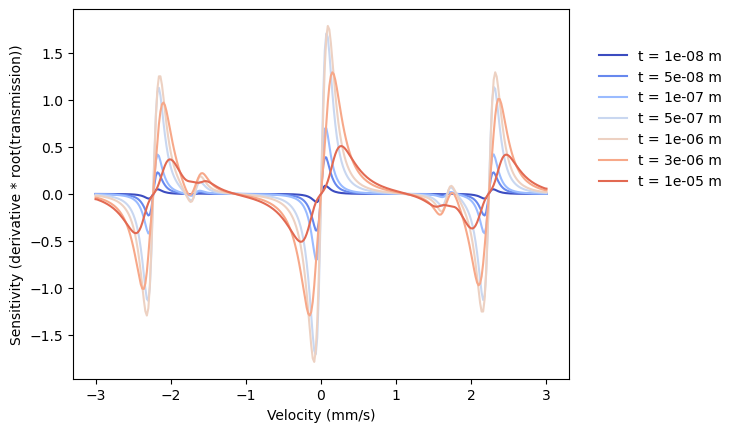

In [139]:
# Optimization of absorber thickneess. 


v = np.linspace(-3,3,300)
thicknesses = [10e-9, 50e-9, 100e-9, 500e-9, 1e-6, 3e-6, 10e-6]
spectrum = []
sensitivity = []

for i, t in enumerate(thicknesses):
    absorber.thickness_m = t
    absorber.update_params()
    moss_Fe_Fe = Mossbauer(sourceFe, absorber)   
    transmission =  moss_Fe_Fe.total_transmission_rate_attenuated(v)
    derivative = np.gradient(transmission, v[1]-v[0])
    spectrum.append(transmission)
    sensitivity.append(derivative*np.sqrt(transmission))

cmap = plt.get_cmap('coolwarm')

for i, t in enumerate(thicknesses):

    plt.plot(v, spectrum[i], color = cmap(i/len(thicknesses)),label = f't = {t:.0e} m')

    plt.legend(frameon=False, loc = (1.05,0.5))

    plt.xlabel('Velocity (mm/s)')
    plt.ylabel('Transmission')
    plt.ylim(0,1)


plt.figure()
for i, t in enumerate(thicknesses):

    plt.plot(v, sensitivity[i], color = cmap(i/len(thicknesses)),label = f't = {t:.0e} m')

    plt.legend(frameon=False, loc = (1.05,0.5))

    plt.xlabel('Velocity (mm/s)')
    plt.ylabel('Sensitivity (derivative * root(transmission))')



In [163]:
# Optimization of absorber thickneess. 

derivative_max = []
sensitivity_max = []

v = np.linspace(-0.5,0.5,200)
thicknesses = np.logspace(-8, -5, 50)
sensitivity = []
optimal_velocity =[]

for i, t in enumerate(thicknesses):
    absorber.thickness_m = t
    absorber.update_params()
    moss_Fe_Fe = Mossbauer(sourceFe, absorber)    
    transmission = moss_Fe_Fe.total_transmission_rate_attenuated(v)
    derivative = np.gradient(transmission, v[1]-v[0])
    derivative_max.append(np.max(derivative))
    sensitivity_max.append(np.max(derivative*np.sqrt(transmission)))
    optimal_velocity.append(v[np.argmax(derivative*np.sqrt(transmission))])

Optimal thickness: 791 nm


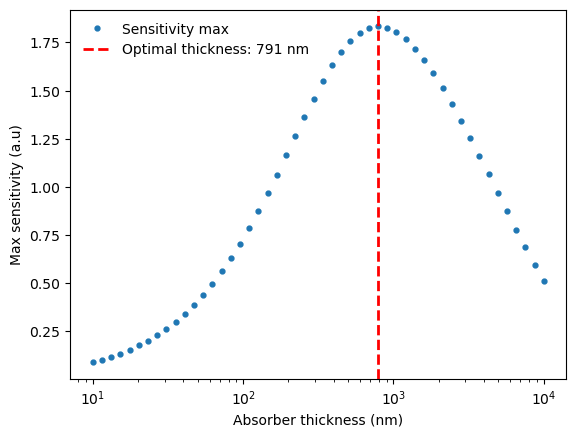

In [164]:
#plt.semilogx(thicknesses*1e9, derivative_max)
plt.semilogx(thicknesses*1e9, sensitivity_max, '.', markersize = 7, label='Sensitivity max')
t_optimal = thicknesses[np.argmax(sensitivity_max)]
print(f'Optimal thickness: {t_optimal*1e9:.0f} nm')
plt.axvline(t_optimal*1e9, color='red', linestyle='--',linewidth = 2, label=f'Optimal thickness: {t_optimal*1e9:.0f} nm')
plt.xlabel('Absorber thickness (nm)')
plt.ylabel('Max sensitivity (a.u)')
plt.legend(frameon=False)

Optimal thickness: 791 nm


(0.0, 0.3)

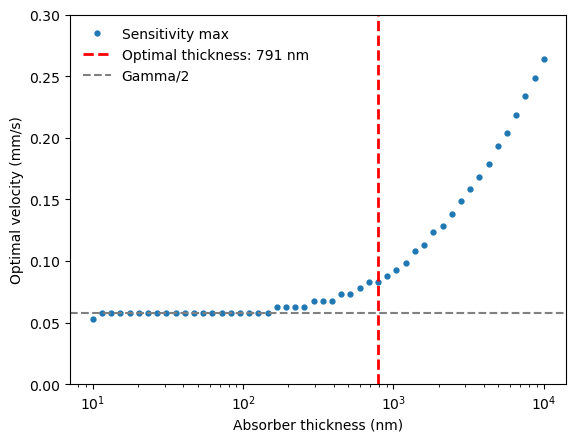

In [171]:
#plt.semilogx(thicknesses*1e9, derivative_max)
plt.semilogx(thicknesses*1e9, np.array(optimal_velocity), '.', markersize = 7, label='Sensitivity max')
t_optimal = thicknesses[np.argmax(sensitivity_max)]
print(f'Optimal thickness: {t_optimal*1e9:.0f} nm')
plt.axvline(t_optimal*1e9, color='red', linestyle='--',linewidth = 2, label=f'Optimal thickness: {t_optimal*1e9:.0f} nm')
plt.xlabel('Absorber thickness (nm)')
plt.ylabel('Optimal velocity (mm/s)')
plt.axhline(Gamma_tot/4, color='gray', linestyle='--', label='Gamma/2')
plt.legend(frameon=False)
plt.ylim(0,0.3)